# BiLSTM + Attention Seq2Seq — Akkadian → English Machine Translation

**Enhanced model** with:
- ✅ **Bahdanau (additive) Attention** — decoder attends over all encoder hidden states
- ✅ **Byte Pair Encoding (BPE)** via `tokenizers` library — reduces OOV rate on rare Akkadian sub-words
- ✅ **Label Smoothing** — regularises the softmax target distribution
- ✅ **Learning Rate Scheduling** — ReduceLROnPlateau to reduce LR when validation loss stalls
- ✅ **Beam Search decoding** — replaces greedy decode at inference, gives better translations
- ✅ Evaluation via BLEU + chrF++

## 0. Imports & Seeds

In [1]:
import sys
print(sys.executable)

c:\Users\surya\GPUenv\Scripts\python.exe


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sacrebleu import corpus_bleu, corpus_chrf
from tqdm import tqdm
import random
import numpy as np
import heapq

# BPE tokenizer
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. Load & Clean Data

In [3]:
df = pd.read_csv("data.csv")

df = df[['transliteration', 'translation']].dropna()
df = df.rename(columns={'transliteration': 'source'})

def clean_text(text):
    text = text.lower()
    text = text.replace('"', '')
    text = text.replace('<gap>', ' <sep> ')
    return text

df['source'] = df['source'].apply(clean_text)
df['translation'] = df['translation'].apply(clean_text)

print(f"Total samples: {len(df)}")

Total samples: 62196


## 2. Train / Validation / Test Split

Split **before** BPE training to avoid data leakage. 80 / 10 / 10.

In [4]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 49756, Val: 6220, Test: 6220


## 3. Byte Pair Encoding (BPE) Tokenisation

### Why BPE?
Akkadian transliterations contain many rare morphological variants.  
BPE learns a shared sub-word vocabulary from the training corpus, so:
- Rare tokens are split into known sub-word pieces → **fewer `<unk>` tokens**
- Vocabulary size stays manageable
- Morphological structure is implicitly captured

We train **separate** BPE models for source (Akkadian) and target (English).

In [5]:
# # Special tokens — BPE trainer needs to know them so they are never split
# SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>", "<sep>"]

# def train_bpe(texts, vocab_size=4000, special_tokens=SPECIAL_TOKENS):
#     """
#     Train a BPE tokenizer on a list of strings.
#     Returns the fitted Tokenizer object.
#     """
#     tokenizer = Tokenizer(BPE(unk_token="<unk>"))
#     tokenizer.pre_tokenizer = Whitespace()
#     trainer = BpeTrainer(
#         vocab_size=vocab_size,
#         special_tokens=special_tokens,
#         min_frequency=2,
#         show_progress=True,
#     )
#     tokenizer.train_from_iterator(texts, trainer=trainer)
#     return tokenizer


# print("Training source (Akkadian) BPE tokenizer...")
# src_tokenizer = train_bpe(train_df['source'].tolist(), vocab_size=4000)

# print("\nTraining target (English) BPE tokenizer...")
# tgt_tokenizer = train_bpe(train_df['translation'].tolist(), vocab_size=6000)

# SRC_VOCAB_SIZE = src_tokenizer.get_vocab_size()
# TGT_VOCAB_SIZE = tgt_tokenizer.get_vocab_size()
# print(f"\nSource BPE vocab size : {SRC_VOCAB_SIZE}")
# print(f"Target BPE vocab size : {TGT_VOCAB_SIZE}")

# # Convenience: token id helpers
# PAD_IDX = tgt_tokenizer.token_to_id("<pad>")
# SOS_IDX = tgt_tokenizer.token_to_id("<sos>")
# EOS_IDX = tgt_tokenizer.token_to_id("<eos>")
# print(f"PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}")

In [6]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

SPECIAL_TOKENS = ["<pad>", "<unk>", "<sos>", "<eos>", "<sep>"]

def train_bpe(texts, vocab_size):
    tokenizer = Tokenizer(BPE(unk_token="<unk>"))
    tokenizer.pre_tokenizer = Whitespace()

    trainer = BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=SPECIAL_TOKENS,
        min_frequency=2
    )

    tokenizer.train_from_iterator(texts, trainer=trainer)
    return tokenizer

src_tokenizer = train_bpe(train_df['source'].tolist(), 4000)
tgt_tokenizer = train_bpe(train_df['translation'].tolist(), 6000)

### 3a. Encode splits with BPE

In [7]:
# def encode_bpe(texts, tokenizer):
#     """Batch-encode a list of strings; returns list of int-id lists."""
#     return [enc.ids for enc in tokenizer.encode_batch(texts)]


# for split_df in [train_df, val_df, test_df]:
#     split_df['src_ids'] = encode_bpe(split_df['source'].tolist(), src_tokenizer)
#     # Wrap target with <sos> / <eos>
#     raw_tgt_ids = encode_bpe(split_df['translation'].tolist(), tgt_tokenizer)
#     split_df['tgt_ids'] = [[SOS_IDX] + ids + [EOS_IDX] for ids in raw_tgt_ids]

# # Quick sanity check
# sample_src = train_df.iloc[0]['source']
# sample_ids = train_df.iloc[0]['src_ids']
# print("Source  :", sample_src)
# print("BPE ids :", sample_ids[:15], "...")
# print("Decoded :", src_tokenizer.decode(sample_ids))

In [8]:
def encode_bpe(texts, tokenizer):
    return [enc.ids for enc in tokenizer.encode_batch(texts)]

# PAD_IDX = tgt_tokenizer.token_to_id("<pad>")
SRC_PAD_IDX = src_tokenizer.token_to_id("<pad>")
TGT_PAD_IDX = tgt_tokenizer.token_to_id("<pad>")
SOS_IDX = tgt_tokenizer.token_to_id("<sos>")
EOS_IDX = tgt_tokenizer.token_to_id("<eos>")

for split_df in [train_df, val_df, test_df]:
    split_df['src_ids'] = encode_bpe(split_df['source'].tolist(), src_tokenizer)

    tgt_ids_raw = encode_bpe(split_df['translation'].tolist(), tgt_tokenizer)
    split_df['tgt_ids'] = [[SOS_IDX] + ids + [EOS_IDX] for ids in tgt_ids_raw]

In [9]:
def filter_by_length(df, max_len=80):
    df['src_len'] = df['src_ids'].apply(len)
    df['tgt_len'] = df['tgt_ids'].apply(len)

    df = df[(df['src_len'] <= max_len) & (df['tgt_len'] <= max_len)]

    # sort for efficient batching
    df = df.sort_values(by='src_len').reset_index(drop=True)

    return df

train_df = filter_by_length(train_df, 80)
val_df   = filter_by_length(val_df, 80)
test_df  = filter_by_length(test_df, 80)

print(f"After filtering → Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

After filtering → Train: 37325, Val: 4687, Test: 4653


## 4. Dataset & DataLoader

In [10]:
class TranslationDataset(Dataset):
    def __init__(self, df):
        self.src = df['src_ids'].tolist()
        self.tgt = df['tgt_ids'].tolist()

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return torch.tensor(self.src[idx]), torch.tensor(self.tgt[idx])


def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, padding_value=SRC_PAD_IDX)
    tgt = pad_sequence(tgt, padding_value=TGT_PAD_IDX)
    # src = pad_sequence(src, padding_value=PAD_IDX)  # (src_len, batch)
    # tgt = pad_sequence(tgt, padding_value=PAD_IDX)  # (tgt_len, batch)
    return src, tgt


train_dataset = TranslationDataset(train_df)
val_dataset   = TranslationDataset(val_df)
test_dataset  = TranslationDataset(test_df)

BATCH_SIZE = 32
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train batches: 1167 | Val: 147 | Test: 146


## 5. Model — BiLSTM Encoder + Bahdanau Attention + LSTM Decoder

### Architecture overview

```
SOURCE  →  Embedding  →  BiLSTM  →  encoder_outputs  (src_len, batch, 2·H)
                                 →  hidden/cell  projected to (1, batch, H)

DECODER step t:
  1. Attention score:  e_t_i  = v^T · tanh( W_h·encoder_outputs[i] + W_s·decoder_hidden )
  2. Attention weight: α_t    = softmax(e_t)
  3. Context vector:   c_t    = Σ α_t_i · encoder_outputs[i]      (batch, 2·H)
  4. LSTM input:       [emb(y_{t-1}) ; c_t]                        (batch, emb+2H)
  5. Output projection: fc( [lstm_out ; c_t] )  →  vocab logits
```

In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers=2, dropout=0.5):
        super().__init__()
        self.hid_dim    = hid_dim
        self.n_layers   = n_layers
        # self.embedding  = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=SRC_PAD_IDX)
        self.dropout    = nn.Dropout(dropout)
        self.lstm       = nn.LSTM(
            emb_dim, hid_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=False
        )
        # Project concatenated bi-directional hidden/cell to decoder size
        self.fc_hidden = nn.Linear(hid_dim * 2, hid_dim)
        self.fc_cell   = nn.Linear(hid_dim * 2, hid_dim)

    def forward(self, src):
        # src: (src_len, batch)
        embedded = self.dropout(self.embedding(src))          # (src_len, batch, emb_dim)
        outputs, (hidden, cell) = self.lstm(embedded)
        # outputs : (src_len, batch, 2·H)  — all timesteps, both directions
        # hidden  : (2·n_layers, batch, H)

        # Take the top-layer forward & backward states and merge
        # hidden[-2] = top fwd, hidden[-1] = top bwd
        hidden = torch.tanh(self.fc_hidden(
            torch.cat((hidden[-2], hidden[-1]), dim=1)
        )).unsqueeze(0)                                       # (1, batch, H)
        cell   = torch.tanh(self.fc_cell(
            torch.cat((cell[-2], cell[-1]), dim=1)
        )).unsqueeze(0)                                       # (1, batch, H)

        return outputs, hidden, cell                          # outputs needed for attention


class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) attention.
    score(s, h_i) = v^T · tanh( W_decoder·s + W_encoder·h_i )
    """
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()
        self.W_encoder = nn.Linear(enc_hid_dim * 2, dec_hid_dim, bias=False)
        self.W_decoder = nn.Linear(dec_hid_dim,     dec_hid_dim, bias=False)
        self.v         = nn.Linear(dec_hid_dim, 1,  bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask=None):
        """
        decoder_hidden  : (1, batch, dec_hid)
        encoder_outputs : (src_len, batch, 2·enc_hid)
        Returns:
            context  : (batch, 2·enc_hid)
            weights  : (batch, src_len)   — attention weights (for visualisation)
        """
        src_len = encoder_outputs.shape[0]
        # Repeat decoder hidden across all src positions
        dec_h = decoder_hidden.squeeze(0).unsqueeze(1).repeat(1, src_len, 1)  # (batch, src_len, dec_hid)
        enc   = encoder_outputs.permute(1, 0, 2)                              # (batch, src_len, 2·enc_hid)

        energy = torch.tanh(self.W_decoder(dec_h) + self.W_encoder(enc))      # (batch, src_len, dec_hid)
        scores = self.v(energy).squeeze(2)                                     # (batch, src_len)

        if src_mask is not None:
            scores = scores.masked_fill(src_mask == 0, float('-inf'))

        weights = F.softmax(scores, dim=1)                                     # (batch, src_len)
        context = torch.bmm(weights.unsqueeze(1), enc).squeeze(1)             # (batch, 2·enc_hid)
        return context, weights


class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout=0.5):
        super().__init__()
        self.attention = BahdanauAttention(enc_hid_dim, dec_hid_dim)
        # self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=TGT_PAD_IDX)
        self.dropout   = nn.Dropout(dropout)
        # LSTM input: embedding + context vector
        self.lstm      = nn.LSTM(emb_dim + enc_hid_dim * 2, dec_hid_dim)
        # Output projection: LSTM output + context vector → vocab logits
        self.fc        = nn.Linear(dec_hid_dim + enc_hid_dim * 2, output_dim)

    def forward(self, input_token, hidden, cell, encoder_outputs, src_mask=None):
        """
        input_token     : (batch,)
        hidden / cell   : (1, batch, dec_hid)
        encoder_outputs : (src_len, batch, 2·enc_hid)
        """
        input_token = input_token.unsqueeze(0)                          # (1, batch)
        embedded    = self.dropout(self.embedding(input_token))         # (1, batch, emb_dim)

        context, attn_weights = self.attention(hidden, encoder_outputs, src_mask)
        context_expanded = context.unsqueeze(0)                         # (1, batch, 2·enc_hid)

        lstm_input = torch.cat((embedded, context_expanded), dim=2)     # (1, batch, emb+2·enc_hid)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        # Concat LSTM output with context for richer projection
        prediction = self.fc(
            torch.cat((output.squeeze(0), context), dim=1)
        )                                                               # (batch, output_dim)
        return prediction, hidden, cell, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, device):
        super().__init__()
        self.encoder     = encoder
        self.decoder     = decoder
        self.src_pad_idx = src_pad_idx
        self.device      = device

    def make_src_mask(self, src):
        # src: (src_len, batch)  →  mask: (batch, src_len)  1=real token, 0=pad
        return (src != self.src_pad_idx).permute(1, 0)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = tgt.shape[1]
        tgt_len    = tgt.shape[0]
        vocab_size = self.decoder.fc.out_features

        outputs      = torch.zeros(tgt_len, batch_size, vocab_size).to(self.device)
        src_mask     = self.make_src_mask(src)
        encoder_outputs, hidden, cell = self.encoder(src)

        input_token = tgt[0]   # <sos>
        for t in range(1, tgt_len):
            output, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
            outputs[t] = output
            top1       = output.argmax(1)
            input_token = tgt[t] if torch.rand(1).item() < teacher_forcing_ratio else top1

        return outputs

## 6. Initialise Model, Optimiser & Loss

**Label Smoothing** (ε=0.1) softens the one-hot targets, acting as regularisation and preventing over-confident predictions.

In [12]:
# EMB_DIM   = 256
# HID_DIM   = 512
EMB_DIM = 128
HID_DIM = 256
N_LAYERS  = 2      # stacked BiLSTM layers in encoder
DROPOUT   = 0.5
LABEL_SMOOTHING = 0.1

SRC_VOCAB_SIZE = src_tokenizer.get_vocab_size()
TGT_VOCAB_SIZE = tgt_tokenizer.get_vocab_size()

encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM, n_layers=N_LAYERS, dropout=DROPOUT)
decoder = AttentionDecoder(TGT_VOCAB_SIZE, EMB_DIM, HID_DIM, HID_DIM, dropout=DROPOUT)
# model   = Seq2SeqAttention(encoder, decoder, src_pad_idx=PAD_IDX, device=device).to(device)
model   = Seq2SeqAttention(encoder, decoder, src_pad_idx=SRC_PAD_IDX, device=device).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ReduceLROnPlateau: halve LR if val loss doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# CrossEntropyLoss with label smoothing & PAD ignored
# criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTHING)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX, label_smoothing=LABEL_SMOOTHING)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 9,640,560


## 7. Inference Helpers

### 7a. Greedy decode

In [13]:
def translate_greedy(model, sentence, src_tokenizer, tgt_tokenizer, device, max_len=50):
    """Greedy decode a single source sentence."""
    model.eval()
    src_ids    = src_tokenizer.encode(sentence).ids
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)
    src_mask   = model.make_src_mask(src_tensor)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    input_token = torch.tensor([SOS_IDX]).to(device)
    output_ids  = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell, _ = model.decoder(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
        pred_id = output.argmax(1).item()
        if pred_id == EOS_IDX:
            break
        output_ids.append(pred_id)
        input_token = torch.tensor([pred_id]).to(device)

    return tgt_tokenizer.decode(output_ids)

### 7b. Beam Search decode

Beam search maintains the top-k partial hypotheses at each step, yielding higher-quality translations than greedy at inference time.

In [14]:
def translate_beam(model, sentence, src_tokenizer, tgt_tokenizer, device,
                   beam_size=4, max_len=50, length_penalty=0.7):
    """
    Beam search decoding.
    length_penalty: score /= len^α  (α=0 means no penalty; α=1 strongly favours longer seqs)
    Returns the best hypothesis as a decoded string.
    """
    model.eval()
    src_ids    = src_tokenizer.encode(sentence).ids
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)
    src_mask   = model.make_src_mask(src_tensor)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor)

    # Each beam: (log_prob, token_ids, hidden, cell)
    beams = [(0.0, [SOS_IDX], hidden, cell)]
    completed = []

    for _ in range(max_len):
        all_candidates = []
        for log_prob, ids, h, c in beams:
            last_token = torch.tensor([ids[-1]]).to(device)
            with torch.no_grad():
                output, h_new, c_new, _ = model.decoder(
                    last_token, h, c, encoder_outputs, src_mask
                )
            log_probs = F.log_softmax(output.squeeze(0), dim=-1)  # (vocab,)
            topk_lp, topk_idx = log_probs.topk(beam_size)

            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                candidate = (log_prob + lp, ids + [idx], h_new, c_new)
                if idx == EOS_IDX:
                    pen_score = (log_prob + lp) / (len(ids) ** length_penalty)
                    completed.append((pen_score, ids[1:]))  # strip <sos>
                else:
                    all_candidates.append(candidate)

        # Keep top beam_size by (raw) log-prob
        beams = sorted(all_candidates, key=lambda x: x[0], reverse=True)[:beam_size]
        if not beams:
            break

    if completed:
        best_ids = max(completed, key=lambda x: x[0])[1]
    else:
        best_ids = beams[0][1][1:]  # strip <sos>

    return tgt_tokenizer.decode(best_ids)

## 8. Evaluation Function

In [15]:
def evaluate_model(model, df_split, src_tokenizer, tgt_tokenizer, device, beam=True, beam_size=4):
    """
    Evaluate on a dataset split.
    Returns BLEU, chrF++ (corpus-level).
    """
    preds, refs = [], []

    # decode_fn = (
    #     lambda s: translate_beam(model, s, src_tokenizer, tgt_tokenizer, device, beam_size=beam_size)
    #     if beam
    #     else lambda s: translate_greedy(model, s, src_tokenizer, tgt_tokenizer, device)
    # )

    if beam:
        decode_fn = lambda s: translate_beam(
            model, s, src_tokenizer, tgt_tokenizer, device, beam_size=beam_size
        )
    else:
        decode_fn = lambda s: translate_greedy(
            model, s, src_tokenizer, tgt_tokenizer, device
        )

    for _, row in df_split.iterrows():
        src = row['source']
        ref = row['translation'].replace("<sep>", " ").strip()
        pred = decode_fn(src).replace("<sep>", " ").strip()
        preds.append(pred)
        refs.append(ref)

    bleu = corpus_bleu(preds, [refs]).score
    chrf = corpus_chrf(preds, [refs]).score
    return bleu, chrf

## 9. Training Loop

- Gradient clipping (`max_norm=1.0`)
- Validation loss + BLEU/chrF++ tracked every epoch
- **ReduceLROnPlateau** scheduler steps on val loss
- Best checkpoint saved on val loss; early stopping with patience=10

In [16]:
N_EPOCHS  = 100
CLIP      = 1.0
PATIENCE  = 10
BEST_PATH = "bilstm_attention_bpe_best.pt"

best_val_loss    = float('inf')
patience_counter = 0
history          = []

for epoch in range(N_EPOCHS):

    # ── Training ──────────────────────────────────────────────
    model.train()
    train_loss = 0

    for src, tgt in tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [Train]"):
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output     = model(src, tgt)                      # (tgt_len, batch, vocab)
        output_dim = output.shape[-1]

        output = output[1:].view(-1, output_dim)           # skip <sos>
        tgt    = tgt[1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ── Validation loss ───────────────────────────────────────
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            output   = model(src, tgt, teacher_forcing_ratio=0.0)
            output   = output[1:].view(-1, output.shape[-1])
            tgt_flat = tgt[1:].reshape(-1)
            val_loss += criterion(output, tgt_flat).item()

    avg_val_loss = val_loss / len(val_loader)

    # Step scheduler
    scheduler.step(avg_val_loss)

    # ── BLEU / chrF++ (greedy, fast) ──────────────────────────
    val_bleu, val_chrf = evaluate_model(
        model, val_df, src_tokenizer, tgt_tokenizer, device, beam=False
    )

    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss':   avg_val_loss,
        'val_bleu':   val_bleu,
        'val_chrf':   val_chrf,
        'lr': optimizer.param_groups[0]['lr'],
    })

    print(f"\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} "
          f"| Val BLEU: {val_bleu:.2f} | Val chrF++: {val_chrf:.2f} "
          f"| LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ── Checkpoint ────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_PATH)
        print(f"  ✅ New best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

print("\nTraining complete.")

Epoch 1/100 [Train]: 100%|██████████| 1167/1167 [03:32<00:00,  5.50it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Epoch 1 | Train Loss: 5.9007 | Val Loss: 6.3251 | Val BLEU: 1.42 | Val chrF++: 14.74 | LR: 0.001000
  ✅ New best model saved (val_loss=6.3251)


Epoch 2/100 [Train]: 100%|██████████| 1167/1167 [03:32<00:00,  5.50it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Epoch 2 | Train Loss: 5.3769 | Val Loss: 6.1910 | Val BLEU: 1.98 | Val chrF++: 17.56 | LR: 0.001000
  ✅ New best model saved (val_loss=6.1910)


Epoch 3/100 [Train]: 100%|██████████| 1167/1167 [03:52<00:00,  5.03it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


...


Epoch 98 | Train Loss: 2.4296 | Val Loss: 4.9232 | Val BLEU: 20.06 | Val chrF++: 44.63 | LR: 0.000031
  ⏳ No improvement (3/10)


Epoch 99/100 [Train]: 100%|██████████| 1167/1167 [03:20<00:00,  5.82it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Epoch 99 | Train Loss: 2.4323 | Val Loss: 4.9226 | Val BLEU: 20.11 | Val chrF++: 44.70 | LR: 0.000016
  ⏳ No improvement (4/10)


Epoch 100/100 [Train]: 100%|██████████| 1167/1167 [03:19<00:00,  5.85it/s]
That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



Epoch 100 | Train Loss: 2.4330 | Val Loss: 4.9162 | Val BLEU: 20.50 | Val chrF++: 44.59 | LR: 0.000016
  ✅ New best model saved (val_loss=4.9162)

Training complete.


## 10. Final Evaluation on Test Set

Load best checkpoint and evaluate with **beam search** (beam_size=4).

In [17]:
model.load_state_dict(torch.load(BEST_PATH, map_location=device))

# Greedy
test_bleu_greedy, test_chrf_greedy = evaluate_model(
    model, test_df, src_tokenizer, tgt_tokenizer, device, beam=False
)

# Beam search
test_bleu_beam, test_chrf_beam = evaluate_model(
    model, test_df, src_tokenizer, tgt_tokenizer, device, beam=True, beam_size=4
)

print("=" * 50)
print("  TEST SET RESULTS (BiLSTM + Attention + BPE)")
print("=" * 50)
print(f"  Greedy  — BLEU: {test_bleu_greedy:.2f}  chrF++: {test_chrf_greedy:.2f}")
print(f"  Beam-4  — BLEU: {test_bleu_beam:.2f}  chrF++: {test_chrf_beam:.2f}")
print("=" * 50)

C:\Users\surya\AppData\Local\Temp\ipykernel_36396\248495386.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_PATH, map_location=devi

  TEST SET RESULTS (BiLSTM + Attention + BPE)
  Greedy  — BLEU: 21.29  chrF++: 45.90
  Beam-4  — BLEU: 25.44  chrF++: 46.18


## 11. Training History

In [18]:
history_df = pd.DataFrame(history)
print(history_df.to_string(index=False))

 epoch  train_loss  val_loss  val_bleu  val_chrf       lr
     1    5.900735  6.325050  1.423208 14.736625 0.001000
     2    5.376877  6.190978  1.976334 17.558832 0.001000
     3    5.037016  6.090208  2.567696 20.120845 0.001000
     4    4.789377  5.974723  3.105741 21.714224 0.001000
     5    4.593467  5.922166  3.659615 23.296422 0.001000
     6    4.439856  5.855381  4.170516 24.748147 0.001000
     7    4.315266  5.786021  4.389011 25.366143 0.001000
     8    4.193088  5.737608  4.933972 26.519258 0.001000
     9    4.101841  5.728530  5.181251 27.241506 0.001000
    10    4.012236  5.692850  5.557374 27.994382 0.001000
    11    3.949741  5.678514  5.540709 28.031520 0.001000
    12    3.876282  5.687023  5.827969 28.841135 0.001000
    13    3.819119  5.641144  6.023744 29.214673 0.001000
    14    3.763455  5.622204  6.228876 29.781157 0.001000
    15    3.713876  5.600364  6.873409 30.557051 0.001000
    16    3.668149  5.607257  6.677319 30.791818 0.001000
    17    3.62

## 12. Attention Visualisation

Inspect which source sub-words the model attends to when generating each target token.

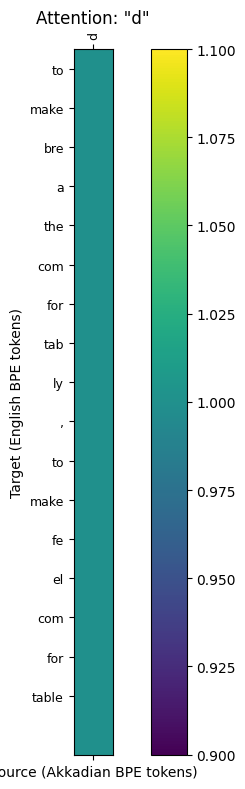

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def get_attention(model, sentence, src_tokenizer, tgt_tokenizer, device, max_len=50):
    """Return (translated_tokens, src_tokens, attention_matrix)."""
    model.eval()
    src_ids     = src_tokenizer.encode(sentence).ids
    src_tokens  = [src_tokenizer.id_to_token(i) for i in src_ids]
    src_tensor  = torch.tensor(src_ids).unsqueeze(1).to(device)
    src_mask    = model.make_src_mask(src_tensor)

    with torch.no_grad():
        enc_outputs, hidden, cell = model.encoder(src_tensor)

    input_token  = torch.tensor([SOS_IDX]).to(device)
    output_ids   = []
    attentions   = []

    for _ in range(max_len):
        with torch.no_grad():
            output, hidden, cell, attn = model.decoder(
                input_token, hidden, cell, enc_outputs, src_mask
            )
        attentions.append(attn.squeeze(0).cpu().numpy())   # (src_len,)
        pred_id = output.argmax(1).item()
        if pred_id == EOS_IDX:
            break
        output_ids.append(pred_id)
        input_token = torch.tensor([pred_id]).to(device)

    tgt_tokens = [tgt_tokenizer.id_to_token(i) for i in output_ids]
    attn_matrix = np.array(attentions)  # (tgt_len, src_len)
    return tgt_tokens, src_tokens, attn_matrix


def plot_attention(sentence, tgt_tokens, src_tokens, attn_matrix):
    fig, ax = plt.subplots(figsize=(max(8, len(src_tokens)), max(6, len(tgt_tokens) // 2)))
    im = ax.matshow(attn_matrix, cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_yticks(range(len(tgt_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90, fontsize=9)
    ax.set_yticklabels(tgt_tokens, fontsize=9)
    ax.set_xlabel('Source (Akkadian BPE tokens)')
    ax.set_ylabel('Target (English BPE tokens)')
    ax.set_title(f'Attention: "{sentence[:60]}"')
    plt.tight_layout()
    plt.savefig('attention_map.png', dpi=150)
    plt.show()


# Run on a sample from the test set
sample_sentence = test_df.iloc[0]['source']
tgt_tok, src_tok, attn = get_attention(model, sample_sentence, src_tokenizer, tgt_tokenizer, device)
plot_attention(sample_sentence, tgt_tok, src_tok, attn)